## Parte I — Contexto, Problema y Marco Teórico del Proyecto

> *Sección agregada para dar al proyecto una narrativa completa de portafolio
> profesional: contexto de negocio, problema, objetivos, justificación y marco
> teórico, antes de entrar al desarrollo técnico (Parte II, ya existente).*


### 1. Introducción

El **mantenimiento predictivo** es uno de los casos de uso más maduros y rentables de la
analítica avanzada en la **Industria 4.0**. Las plantas industriales —refinerías, plantas de
tratamiento de agua, minería, manufactura— dependen de equipos críticos como bombas,
compresores y motores que operan de forma continua durante meses o años. Estos equipos están
instrumentados con decenas de sensores (presión, vibración, temperatura, flujo, corriente) que
generan telemetría de alta frecuencia, creando una oportunidad para **anticipar fallas antes de
que ocurran** en lugar de reaccionar después del hecho.

Este proyecto analiza la telemetría de **52 sensores de una bomba industrial**, registrada cada
minuto durante 152 días (abril–agosto de 2018), junto con la variable `machine_status` que
indica si la máquina estaba en operación **normal**, en **recuperación** tras un evento, o
**dañada** (`BROKEN`). El objetivo es doble: (1) realizar un análisis exploratorio riguroso que
revele patrones de comportamiento normal y anómalo, y (2) entrenar y validar modelos de
**machine learning supervisado** capaces de distinguir el estado anómalo del normal a partir de
las lecturas de los sensores, como base de un sistema de alerta temprana.

La relevancia del problema va más allá del ejercicio académico: detectar anomalías de forma
temprana y confiable es la piedra angular de cualquier solución comercial de mantenimiento
predictivo, y es exactamente el tipo de capacidad que las empresas industriales buscan comprar
o desarrollar internamente para reducir costos operativos y aumentar la disponibilidad de sus
activos.


### 2. Planteamiento del problema

Las fallas no planificadas en equipos rotativos como bombas industriales generan, típicamente,
los costos operativos más altos de cualquier estrategia de mantenimiento:

- **Paradas no programadas:** detienen la producción de forma abrupta, sin tiempo para
  planificar repuestos, personal o ventanas de mantenimiento, lo que multiplica el costo de la
  intervención frente a un mantenimiento programado.
- **Mantenimiento reactivo (correctivo):** reparar *después* de que el equipo falla es la
  estrategia más costosa y riesgosa: suele implicar daños secundarios a otros componentes,
  tiempos de reparación más largos y, en plantas de proceso continuo, pérdidas de producción
  que pueden superar varias veces el costo de la pieza dañada.
- **Riesgo operativo y de seguridad:** una bomba que falla de forma súbita en procesos críticos
  (ej. tratamiento de agua, petróleo y gas) puede generar riesgos de seguridad, ambientales y de
  cumplimiento normativo, no solo financieros.
- **Información subutilizada:** la planta ya genera telemetría de alta frecuencia, pero sin un
  modelo analítico esa información rara vez se traduce en decisiones de mantenimiento
  anticipadas; los datos existen, pero el conocimiento accionable no.

El problema central que aborda este proyecto es: **¿es posible, a partir de la lectura
simultánea de los 51 sensores de la bomba, distinguir de forma confiable un estado operativo
anómalo (en camino a falla o en recuperación de una falla) de un estado normal, con suficiente
anticipación y precisión para ser útil en una estrategia real de mantenimiento predictivo?**


### 3. Objetivo general

Desarrollar un análisis exploratorio de datos riguroso y un modelo de machine learning capaz de
**detectar comportamientos anómalos** en la telemetría de una bomba industrial, que sirva como
base técnica para una estrategia de **mantenimiento predictivo**, identificando el modelo con la
**mejor capacidad predictiva realista** (no solo la métrica más alta bajo una validación
optimista) para escenarios de negocio en producción.


### 4. Objetivos específicos

1. **Evaluar la calidad de los datos:** cuantificar y tratar valores nulos, duplicados y tipos
   de datos incorrectos, documentando cada decisión.
2. **Identificar patrones de comportamiento:** caracterizar estadísticamente los 51 sensores y
   su relación con el estado de la máquina (`machine_status`).
3. **Detectar valores atípicos (outliers):** aplicar criterios estadísticos (IQR) e
   interpretarlos en el contexto de un sistema con múltiples regímenes operativos.
4. **Entrenar múltiples modelos de clasificación supervisada** (Regresión Logística, Árbol de
   Decisión, Random Forest, KNN, Naive Bayes y XGBoost) para la tarea de detección de anomalías.
5. **Comparar el desempeño de los modelos** con métricas apropiadas para clases desbalanceadas
   (Precision, Recall, F1, ROC-AUC), no solo con Accuracy.
6. **Evaluar el desempeño de forma crítica**, interpretando resultados inusualmente altos en
   lugar de aceptarlos sin cuestionarlos.
7. **Identificar riesgos de sobreajuste o fuga de información (*data leakage*)**, en particular
   los derivados de la naturaleza de **serie de tiempo** del problema.
8. **Seleccionar el modelo más robusto para producción**, considerando no solo la métrica
   técnica sino interpretabilidad, costo computacional y viabilidad de mantenimiento del modelo
   en el tiempo.


### 5. Justificación

Este proyecto se justifica desde tres perspectivas complementarias:

**Perspectiva técnica:** el dataset combina los retos típicos de telemetría industrial real
—series de tiempo de alta frecuencia, fuerte desbalance de clases, alta multicolinealidad entre
sensores y pocos eventos de falla— por lo que es un caso de estudio representativo para aplicar
y poner a prueba buenas prácticas de ciencia de datos: limpieza rigurosa, EDA orientado a
negocio, selección de métricas adecuadas y, crucialmente, **validación honesta** del desempeño.

**Perspectiva empresarial y operativa:** un modelo confiable de detección de anomalías permite
pasar de un mantenimiento **reactivo** (reparar después de la falla) o **basado en calendario**
(reemplazar piezas a intervalos fijos, sin importar su estado real) a un mantenimiento
**predictivo basado en condición**, lo que reduce paradas no planificadas, optimiza el uso de
repuestos y mano de obra, y extiende la vida útil de los activos.

**Perspectiva comercial:** soluciones de este tipo —telemetría + analítica + alertas— son
exactamente lo que clientes industriales (manufactura, agua, energía, minería) buscan adquirir
como parte de su transformación digital. Un modelo bien validado, documentado y con una
narrativa clara de negocio (como el que se construye en este notebook) es la base de un producto
o servicio de mantenimiento predictivo comercializable, y demuestra de forma tangible el tipo de
trabajo que un equipo de ciencia de datos puede entregar a un cliente industrial.


### 6. Marco teórico

**Análisis exploratorio de datos (EDA).** Conjunto de técnicas estadísticas y visuales para
entender la estructura, calidad y patrones de un conjunto de datos antes de modelar: estadística
descriptiva (tendencia central, dispersión, forma de la distribución), detección de valores
faltantes y atípicos, y análisis de relaciones entre variables (correlación, análisis bivariado
y multivariado).

**Machine learning supervisado y clasificación de anomalías.** En este proyecto la detección de
anomalías se aborda como un problema de **clasificación binaria supervisada**: cada registro
(una lectura simultánea de 51 sensores en un instante de tiempo) se etiqueta como `0` (normal) o
`1` (anómalo, agrupando `RECOVERING` y `BROKEN`), y se entrena un modelo que aprende a predecir
esa etiqueta a partir de los valores de los sensores.

**Sensores industriales y mantenimiento predictivo.** Los sensores industriales (presión,
vibración, temperatura, flujo, corriente, etc.) capturan el estado físico de un equipo en tiempo
real. El **mantenimiento predictivo** usa esa telemetría —combinada con modelos estadísticos o de
machine learning— para estimar la condición de un activo y anticipar fallas, en contraste con el
mantenimiento *reactivo* (después de la falla) o *preventivo* (por calendario, sin considerar el
estado real del equipo).

**Modelos de clasificación utilizados:**
- **Regresión Logística:** modelo lineal, rápido y altamente interpretable; sirve como línea
  base.
- **Árbol de Decisión:** modelo no lineal basado en reglas; interpretable pero propenso a
  sobreajuste si no se controla su profundidad.
- **Random Forest:** ensamble de árboles de decisión (*bagging*); reduce el sobreajuste de un
  árbol individual y maneja bien la multicolinealidad entre variables.
- **KNN (K-Nearest Neighbors):** clasifica según la mayoría de los vecinos más cercanos en el
  espacio de variables; sensible a la escala y costoso en inferencia con muchos datos.
- **Naive Bayes:** modelo probabilístico simple basado en independencia condicional; rápido,
  pero con supuestos fuertes que rara vez se cumplen con datos de sensores correlacionados.
- **XGBoost (*Extreme Gradient Boosting*):** ensamble de árboles mediante *boosting* secuencial;
  suele ofrecer el mejor desempeño en datos tabulares estructurados, con buen manejo de clases
  desbalanceadas mediante el parámetro `scale_pos_weight`.

**Métricas de evaluación:**
- **Accuracy (exactitud):** proporción de predicciones correctas; **poco informativa con clases
  desbalanceadas** (un modelo que siempre predice "normal" tendría accuracy alta y sería inútil).
- **Precision (precisión):** de las veces que el modelo predijo "anómalo", qué proporción
  realmente lo era; alta precisión implica pocas falsas alarmas.
- **Recall (sensibilidad):** de las anomalías reales, qué proporción detectó el modelo; alto
  recall implica pocas fallas no detectadas (el error más costoso en mantenimiento predictivo).
- **F1-score:** media armónica entre precisión y recall; resume el balance entre ambos errores.
- **ROC-AUC:** mide la capacidad del modelo de **ordenar** correctamente observaciones anómalas
  por encima de las normales, independientemente del umbral de decisión.

**Sobreajuste (*overfitting*).** Ocurre cuando un modelo aprende patrones específicos de los
datos de entrenamiento (incluyendo ruido) que no generalizan a datos nuevos. Se detecta
comparando el desempeño en entrenamiento vs. prueba, y se mitiga con validación cruzada,
regularización y control de la complejidad del modelo.

**Fuga de información (*data leakage*).** Ocurre cuando el proceso de entrenamiento/validación
le da al modelo, directa o indirectamente, acceso a información que no estaría disponible en el
momento real de la predicción, inflando artificialmente las métricas. En problemas de **series
de tiempo** una de las formas más sutiles y frecuentes de leakage es dividir entrenamiento y
prueba de forma **aleatoria** en vez de **cronológica**: registros consecutivos en el tiempo
suelen ser casi idénticos (alta autocorrelación), así que un split aleatorio puede dejar minutos
casi idénticos en ambos conjuntos, permitiendo que el modelo "memorice" el entorno inmediato de
cada evento anómalo en lugar de aprender un patrón que generalice hacia el futuro. Esta hipótesis
se pone a prueba de forma rigurosa en la **Sección 10.8** de este notebook.

**Validación cruzada y generalización.** La validación cruzada (p. ej. `StratifiedKFold`) entrena
y evalúa el modelo en varias particiones de los datos para estimar qué tan estable es su
desempeño. Es una herramienta poderosa, pero **no es inmune al problema de leakage temporal**
descrito arriba si las particiones también se hacen de forma aleatoria en el tiempo: por eso, en
series de tiempo, se recomienda complementarla (o sustituirla) con una validación **cronológica**
(entrenar con el pasado, probar con el futuro), como se hace explícitamente en este notebook.


## Parte II — Desarrollo Técnico: EDA y Modelado

> *A partir de aquí continúa el desarrollo técnico ya construido previamente
> (Módulos 2, 3, 4 y 5), sin modificaciones respecto a la versión original.*


# Análisis Exploratorio + Machine Learning — Sensores de una Bomba Industrial

**Mantenimiento predictivo a partir de la telemetría de 52 sensores**

Este notebook aplica de forma integral los **Módulos 2, 3, 4 y 5** del curso
*Ciencia de datos con Python para la toma de decisiones*:

- **Módulo 2 — EDA:** estadística descriptiva, distribuciones y visualización.
- **Módulo 3 — Tratamiento de datos y dataviz interactivo:** valores faltantes
  (eliminación vs. imputación), atípicos y gráficos interactivos con Plotly.
- **Módulo 4 — Despliegue:** el resultado alimenta el dashboard `Dash` (`app.py`) del repositorio.
- **Módulo 5 — Machine Learning:** clasificación supervisada del estado de la máquina,
  comparación de varios modelos y selección del mejor.

> Siguiendo el enfoque del curso, cada bloque de código va precedido de una explicación en
> *Markdown* que indica **qué** se hace y **por qué**. El notebook es limpio y completamente
> reproducible.

---

## Contexto de negocio

Una bomba industrial está instrumentada con **52 sensores** que registran una medición
**cada minuto**. La variable `machine_status` etiqueta el estado (`NORMAL`, `RECOVERING`,
`BROKEN`). Una parada no planificada detiene la producción y genera sobrecostos.

**Objetivo:** comprender la telemetría (EDA) y **construir un modelo capaz de detectar el
estado anómalo de la máquina** a partir de los sensores, para anticipar fallas.


## 0. Configuración del entorno e importación de librerías

**Qué:** importamos las librerías de datos (`pandas`, `numpy`), estadística (`scipy`),
visualización (`matplotlib`, `seaborn`, `plotly`) y machine learning (`scikit-learn`).

**Por qué:** centralizar las importaciones hace el notebook reproducible y deja explícitas
las dependencias (listadas en `requirements.txt`).


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import skew, kurtosis, shapiro

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y lectura del dataset

**Qué:** leemos `data/sensor.csv.gz`. El archivo se distribuye **comprimido en gzip**
porque el CSV original (~119 MB) supera el límite de 100 MB por archivo de GitHub; `pandas`
lo descomprime al vuelo. Usamos una ruta relativa para que el notebook sea portable.


In [3]:
from pathlib import Path

candidatos = [Path("data/sensor.csv.gz"), Path("../data/sensor.csv.gz")]
ruta = next((p for p in candidatos if p.exists()), candidatos[0])

df = pd.read_csv(ruta, compression="infer")
print(f"Cargado desde: {ruta.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Cargado desde: D:\nvargas\Downloads\ejercicio_ciencia_datos\pump_sensor_dash\data\sensor.csv.gz
Dimensiones: 220,320 filas x 55 columnas


## 2. Exploración inicial

**Qué:** inspeccionamos las primeras filas (`head`), la forma (`shape`) y la información
general (`info`).

**Por qué:** es el primer contacto con la estructura: cuántos registros y variables hay,
qué representa cada columna y dónde podría haber nulos.


In [4]:
df.head()

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,NaN,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,NaN,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,39.48939,49.06298,31.95202,1.683831,419.8926,NaN,461.4906,468.2206,2.604785,663.2111,400.5426,882.5874,498.5383,979.5755,627.1830,737.6033,846.9182,408.8159,785.2307,704.6937,631.4814,766.1458,702.4431,433.9081,164.7498,339.9630,193.8770,101.70380,42.70833,31.51042,76.82291,30.98958,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [5]:
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    220,320
Columnas: 55


In [6]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

El dataset tiene **220.320 registros** y **55 columnas**: un índice heredado
(`Unnamed: 0`), la marca de tiempo (`timestamp`), **52 sensores** y la etiqueta
`machine_status`.

## 3. Tipos de datos: diagnóstico, transformación y verificación

El curso insiste en **revisar los tipos de datos, transformarlos según el análisis y volver
a revisarlos**. Lo hacemos en tres pasos.

### 3.1 Tipos de datos ANTES de transformar

**Qué/Por qué:** vemos cómo `pandas` infirió cada tipo al leer el CSV. Detectaremos
columnas mal tipadas que conviene corregir.


In [7]:
print("Tipos de datos por columna (resumen):")
print(df.dtypes.value_counts())
print("\nDetalle de columnas no numéricas y la columna índice:")
df[["Unnamed: 0", "timestamp", "machine_status"]].dtypes

Tipos de datos por columna (resumen):
float64    52
object      2
int64       1
Name: count, dtype: int64

Detalle de columnas no numéricas y la columna índice:


Unnamed: 0         int64
timestamp         object
machine_status    object
dtype: object

**Diagnóstico:**

- `timestamp` llegó como **texto** (`object`); para un análisis de serie de tiempo debe ser
  `datetime`.
- `machine_status` llegó como **texto** pero es una **variable categórica** con tres niveles
  ordenables por severidad (`NORMAL` < `RECOVERING` < `BROKEN`).
- Los 52 sensores son **numéricos** (`float64`), lo correcto.
- `Unnamed: 0` es un índice exportado por error (redundante); se eliminará en la limpieza.

### 3.2 Transformación de los tipos necesarios

**Qué:** convertimos `timestamp` a `datetime` y `machine_status` a `category` ordenada.

**Por qué:** `datetime` habilita operaciones temporales (orden, remuestreo, interpolación
por tiempo); `category` ahorra memoria y permite ordenar/segmentar correctamente por estado.


In [8]:
# timestamp -> datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# machine_status -> categórica ordenada por severidad
orden_estado = ["NORMAL", "RECOVERING", "BROKEN"]
df["machine_status"] = pd.Categorical(df["machine_status"],
                                      categories=orden_estado, ordered=True)
print("Transformación aplicada a 'timestamp' y 'machine_status'.")

Transformación aplicada a 'timestamp' y 'machine_status'.


### 3.3 Tipos de datos DESPUÉS de transformar

**Qué/Por qué:** confirmamos que las conversiones se aplicaron correctamente antes de seguir.


In [9]:
df[["timestamp", "machine_status"]].dtypes

timestamp         datetime64[ns]
machine_status          category
dtype: object

In [10]:
# Confirmamos el rango temporal y la frecuencia de muestreo
print("Inicio :", df["timestamp"].min())
print("Fin    :", df["timestamp"].max())
print("Periodo:", (df["timestamp"].max() - df["timestamp"].min()).days, "días")
print("Intervalo más frecuente:\n", df["timestamp"].diff().value_counts().head(1))

Inicio : 2018-04-01 00:00:00
Fin    : 2018-08-31 23:59:00
Periodo: 152 días
Intervalo más frecuente:
 timestamp
0 days 00:01:00    220319
Name: count, dtype: int64


La telemetría cubre **del 1 abr al 31 ago 2018 (152 días)** con muestreo **regular de 1
minuto**: es una **serie de tiempo equiespaciada**, lo que condicionará el tratamiento de
nulos.

## 4. Identificación de valores nulos y tratamiento propuesto

Conforme al **Módulo 3**, cuantificamos los faltantes en **conteo** y **porcentaje**. El
conteo dimensiona el problema; el porcentaje guía la estrategia (regla práctica del curso:
*eliminar* si ≤ 5 %, *imputar* si es mayor).


In [11]:
nulos = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
tabla_nulos = (pd.DataFrame({"Valores_Faltantes": nulos, "Porcentaje_%": pct})
               .query("Valores_Faltantes > 0")
               .sort_values("Porcentaje_%", ascending=False))
print(f"Columnas con nulos: {(nulos > 0).sum()} de {df.shape[1]}")
tabla_nulos

Columnas con nulos: 52 de 55


,Valores_Faltantes,Porcentaje_%
sensor_15,220320,100.00
sensor_50,77017,34.96
sensor_51,15383,6.98
sensor_00,10208,4.63
sensor_07,5451,2.47
sensor_08,5107,2.32
sensor_06,4798,2.18
sensor_09,4595,2.09
sensor_01,369,0.17
sensor_30,261,0.12


In [12]:
import plotly.express as px

In [13]:
fig = px.bar(tabla_nulos.reset_index().rename(columns={"index": "Columna"}),
             x="Columna", y="Porcentaje_%",
             title="Porcentaje de valores faltantes por columna")
fig.add_hline(y=5, line_dash="dash", line_color="red",
              annotation_text="Umbral 5%", annotation_position="top left")
fig.update_layout(xaxis_tickangle=-60, height=500)
fig.show()

### Análisis y tratamiento (por tipo de variable)

| Caso | Columnas | % nulos | Tratamiento |
|------|----------|---------|-------------|
| **Sin información** | `sensor_15` | **100 %** | **Eliminar la columna** |
| **Severos** | `sensor_50` (~35 %), `sensor_51` (~7 %) | > 5 % | **Imputar** |
| **Moderados/mínimos** | `sensor_00`, `sensor_06`–`09`, resto | 0–5 % | **Imputar** |

**Decisión razonada:** la regla del curso sugiere *eliminar filas* cuando los nulos son
≤ 5 %. Sin embargo, **todas las variables numéricas forman una serie de tiempo de 1 minuto**;
borrar filas rompería la cadencia temporal. Por eso, para **todos los sensores** se prefiere
la **imputación por interpolación temporal**, reservando la *eliminación* solo para
`sensor_15` (no tiene ningún valor que interpolar). `machine_status` no tiene nulos, así que
no requiere imputación por moda. El tratamiento se aplica en la sección 6.


## 5. Identificación y manejo de datos duplicados

**Qué:** contamos filas completamente duplicadas y, por ser serie de tiempo, también
**marcas de tiempo repetidas**.

**Por qué:** los duplicados sesgan frecuencias y estadísticas; un `timestamp` repetido sería
un error de registro.


In [14]:
dup_filas = df.duplicated().sum()
dup_ts = df["timestamp"].duplicated().sum()
print(f"Filas completamente duplicadas : {dup_filas}")
print(f"Marcas de tiempo duplicadas    : {dup_ts}")

Filas completamente duplicadas : 0
Marcas de tiempo duplicadas    : 0


**Resultado:** **0 filas duplicadas** y **0 timestamps repetidos**. El registro es
íntegro: **no se elimina ningún registro por duplicidad**. Dejamos la instrucción
documentada como buena práctica (no altera nada porque no hay duplicados).


In [15]:
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensiones tras verificación:", df.shape)

Dimensiones tras verificación: (220320, 55)


## 6. Limpieza y tratamiento aplicado

Aplicamos las decisiones anteriores: (1) eliminar `Unnamed: 0` y `sensor_15`; (2) usar
`timestamp` como índice temporal; (3) imputar los sensores por interpolación temporal.
`machine_status` ya quedó como categórica en la sección 3.


In [16]:
df_clean = df.copy()

# (1) eliminar columnas sin valor analítico
df_clean = df_clean.drop(columns=["Unnamed: 0", "sensor_15"])

# (2) timestamp como índice temporal
df_clean = df_clean.set_index("timestamp").sort_index()

print("Columnas eliminadas: ['Unnamed: 0', 'sensor_15']")
print("Nuevas dimensiones:", df_clean.shape)

Columnas eliminadas: ['Unnamed: 0', 'sensor_15']
Nuevas dimensiones: (220320, 52)


In [17]:
# (3) imputación temporal de los sensores
sensores = df_clean.select_dtypes(include="number").columns.tolist()
nulos_antes = int(df_clean[sensores].isnull().sum().sum())
df_clean[sensores] = (df_clean[sensores]
                      .interpolate(method="time").ffill().bfill())
nulos_despues = int(df_clean[sensores].isnull().sum().sum())
print(f"Nulos en sensores: {nulos_antes:,} -> {nulos_despues:,}")

Nulos en sensores: 124,254 -> 0


El dataset queda **limpio y completo** (`df_clean`), con 51 sensores numéricos sin
nulos y la cadencia de 1 minuto intacta.

## 7. Estadísticas descriptivas (Módulo 2)

Resumimos con `describe()` y luego construimos un cuadro completo de medidas (tendencia
central, dispersión, posición, asimetría, curtosis) para un sensor representativo, más una
comparación por estado de la máquina (descriptivo bivariado categórica vs. numérica).


In [18]:
df_clean[sensores].describe().T[["mean","std","min","25%","50%","75%","max"]].round(2)

,mean,std,min,25%,50%,75%,max
sensor_00,2.27,0.60,0.00,2.42,2.46,2.50,2.55
sensor_01,47.60,3.30,0.00,46.31,48.13,49.48,56.73
sensor_02,50.87,3.67,33.16,50.39,51.65,52.78,56.03
sensor_03,43.75,2.42,31.64,42.84,44.23,45.31,48.22
sensor_04,590.66,144.04,2.80,626.62,632.64,637.62,800.00
sensor_05,73.39,17.30,0.00,69.98,75.58,80.91,100.00
sensor_06,13.21,2.90,0.01,13.32,13.63,14.54,22.25
sensor_07,15.48,3.20,0.00,15.86,16.17,16.43,23.60
sensor_08,14.86,3.00,0.03,15.15,15.45,15.70,24.35
sensor_09,14.49,2.96,0.00,15.01,15.08,15.12,25.00


In [19]:
col = "sensor_04"
s = df_clean[col]
estadisticos = pd.Series({
    "Media": s.mean(), "Desv. estándar": s.std(),
    "Coef. variación (%)": s.std()/s.mean()*100,
    "Mínimo": s.min(), "Q1 (25%)": s.quantile(.25), "Mediana (Q2)": s.median(),
    "Q3 (75%)": s.quantile(.75), "Máximo": s.max(),
    "IQR": s.quantile(.75)-s.quantile(.25),
    "Asimetría (skew)": skew(s), "Curtosis (exceso)": kurtosis(s),
})
print(f"Medidas descriptivas — {col}")
estadisticos.round(3)

Medidas descriptivas — sensor_04


Media                  590.664
Desv. estándar         144.042
Coef. variación (%)     24.386
Mínimo                   2.798
Q1 (25%)               626.620
Mediana (Q2)           632.639
Q3 (75%)               637.616
Máximo                 800.000
IQR                     10.995
Asimetría (skew)        -3.368
Curtosis (exceso)        9.952
dtype: float64

In [20]:
df_clean.groupby("machine_status", observed=True)["sensor_04"].agg(
    Promedio="mean", Desv_Estandar="std", Minimo="min", Mediana="median", Maximo="max"
).round(2)

,Promedio,Desv_Estandar,Minimo,Mediana,Maximo
machine_status,,,,,
NORMAL,625.67,50.82,2.80,633.33,800.00
RECOVERING,93.02,117.95,2.80,3.57,611.69
BROKEN,334.67,173.96,200.12,206.04,612.15


## 8. Análisis de distribuciones (Módulo 2)

**Qué:** histogramas + densidad de varios sensores y una **prueba de normalidad de
Shapiro–Wilk** sobre una muestra.

**Por qué:** verificar simetría y colas pesadas orienta transformaciones y el tipo de prueba
(paramétrica vs. no paramétrica) válida más adelante.


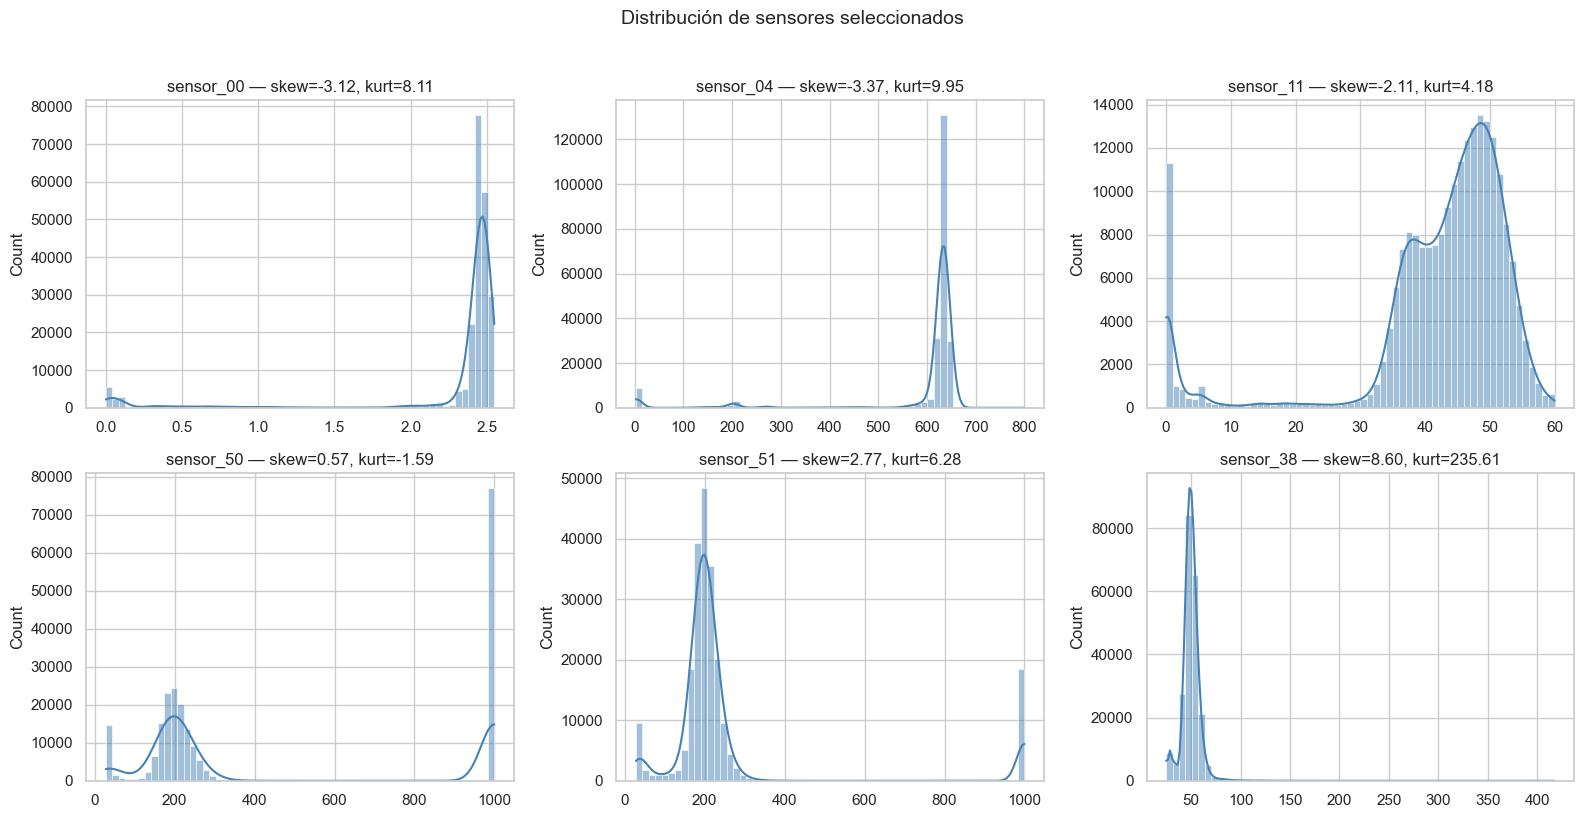

In [21]:
muestra = ["sensor_00","sensor_04","sensor_11","sensor_50","sensor_51","sensor_38"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), muestra):
    sns.histplot(df_clean[c], bins=60, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{c} — skew={skew(df_clean[c]):.2f}, kurt={kurtosis(df_clean[c]):.2f}")
    ax.set_xlabel("")
plt.suptitle("Distribución de sensores seleccionados", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

In [22]:
m = df_clean["sensor_04"].sample(5000, random_state=42)
stat, p = shapiro(m)
print(f"Shapiro-Wilk sensor_04: estadístico={stat:.4f}, p-valor={p:.2e}")
print("Conclusión:", "No normal (se rechaza H0)" if p < 0.05 else "Compatible con normal")

Shapiro-Wilk sensor_04: estadístico=0.3602, p-valor=1.43e-85
Conclusión: No normal (se rechaza H0)


Las distribuciones **no son normales** (asimetría y curtosis altas; Shapiro–Wilk
rechaza la normalidad), comportamiento típico de señales físicas con regímenes operativos
distintos.

## 9. Visualizaciones para identificar patrones y anomalías (Módulo 3)

Usamos **Plotly** para descubrir la estructura de los datos y el comportamiento alrededor de
las fallas.

### 9.1 Distribución de la variable objetivo `machine_status`


In [23]:
conteo = df_clean["machine_status"].value_counts().reset_index()
conteo.columns = ["machine_status", "conteo"]
conteo["porcentaje"] = (conteo["conteo"]/len(df_clean)*100).round(3)
fig = px.bar(conteo, x="machine_status", y="conteo", text="porcentaje",
             color="machine_status", log_y=True,
             title="Distribución de estados de la máquina")
fig.update_traces(texttemplate="%{text}%", textposition="outside")
fig.show()
conteo

,machine_status,conteo,porcentaje
0,NORMAL,205836,93.426
1,RECOVERING,14477,6.571
2,BROKEN,7,0.003


**Hallazgo:** desbalance fuerte —`NORMAL` ≈ 93,4 %, `RECOVERING` ≈ 6,6 % y solo **7
registros `BROKEN`** en cinco meses. Esto será clave para el modelado.

### 9.2 Eventos de falla en el tiempo

In [24]:
fallas = df_clean.index[df_clean["machine_status"] == "BROKEN"]
print("Instantes de falla (BROKEN):")
for f in fallas: print("  -", f)

serie = df_clean["sensor_04"].resample("1h").mean()
fig = go.Figure()
fig.add_trace(go.Scatter(x=serie.index, y=serie.values, mode="lines",
                         name="sensor_04 (media horaria)", line=dict(color="#1f77b4")))
for f in fallas:
    fig.add_vline(x=f, line_dash="dash", line_color="red", opacity=0.6)
fig.update_layout(title="sensor_04 en el tiempo (líneas rojas = fallas BROKEN)",
                  xaxis_title="Tiempo", yaxis_title="sensor_04", height=450)
fig.show()

Instantes de falla (BROKEN):
  - 2018-04-12 21:55:00
  - 2018-04-18 00:30:00
  - 2018-05-19 03:18:00
  - 2018-05-25 00:30:00
  - 2018-06-28 22:00:00
  - 2018-07-08 00:11:00
  - 2018-07-25 14:00:00


Las fallas coinciden con **caídas/saltos abruptos** del sensor: el problema es
**predecible** a partir de la telemetría.

### 9.3 Matriz de correlación entre sensores

In [25]:
corr = df_clean[sensores].corr()
fig = px.imshow(corr, color_continuous_scale="RdBu_r", zmin=-1, zmax=1, aspect="auto",
                title="Mapa de calor de correlaciones entre sensores")
fig.update_layout(height=700); fig.show()

import itertools
pares_altos = [(a,b,round(corr.loc[a,b],2))
               for a,b in itertools.combinations(corr.columns,2) if abs(corr.loc[a,b])>0.9]
print(f"Pares de sensores con |r| > 0.9: {len(pares_altos)}")

Pares de sensores con |r| > 0.9: 68


**65 pares** con |r| > 0,9: alta **redundancia/multicolinealidad**. Modelos basados en
árboles (Random Forest) toleran bien esto; para modelos lineales convendría
selección de variables o PCA.

### 9.4 Detección de valores atípicos (outliers) — método IQR

**Qué:** aplicamos la regla clásica del rango interquartílico (IQR): un valor se marca como
atípico si está por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR`. Lo calculamos para
los 51 sensores.

**Por qué:** complementa el análisis de distribuciones (Sección 8) con un criterio cuantitativo
estándar de detección de atípicos, requerido como parte de un EDA completo.


In [26]:
sensores = df_clean.select_dtypes(include="number").columns.tolist()

filas = []
for s in sensores:
    q1, q3 = df_clean[s].quantile(.25), df_clean[s].quantile(.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = int(((df_clean[s] < li) | (df_clean[s] > ls)).sum())
    filas.append({"sensor": s, "IQR": round(iqr, 3), "n_outliers": n_out,
                  "pct_outliers": round(n_out/len(df_clean)*100, 2)})

tabla_outliers = pd.DataFrame(filas).sort_values("pct_outliers", ascending=False)
print("Top 10 sensores con más outliers (regla IQR 1.5x):")
print(tabla_outliers.head(10).to_string(index=False))
print(f"\nSensores con más de 5% de outliers: {(tabla_outliers['pct_outliers']>5).sum()} de {len(sensores)}")

Top 10 sensores con más outliers (regla IQR 1.5x):
   sensor    IQR  n_outliers  pct_outliers
sensor_20  2.067       59582         27.04
sensor_09  0.109       59110         26.83
sensor_14  2.894       58161         26.40
sensor_19  4.377       58110         26.38
sensor_21  6.665       56065         25.45
sensor_16  4.852       48818         22.16
sensor_17 12.722       37967         17.23
sensor_18  0.140       37910         17.21
sensor_30 69.444       37403         16.98
sensor_51 42.535       35001         15.89

Sensores con más de 5% de outliers: 40 de 51


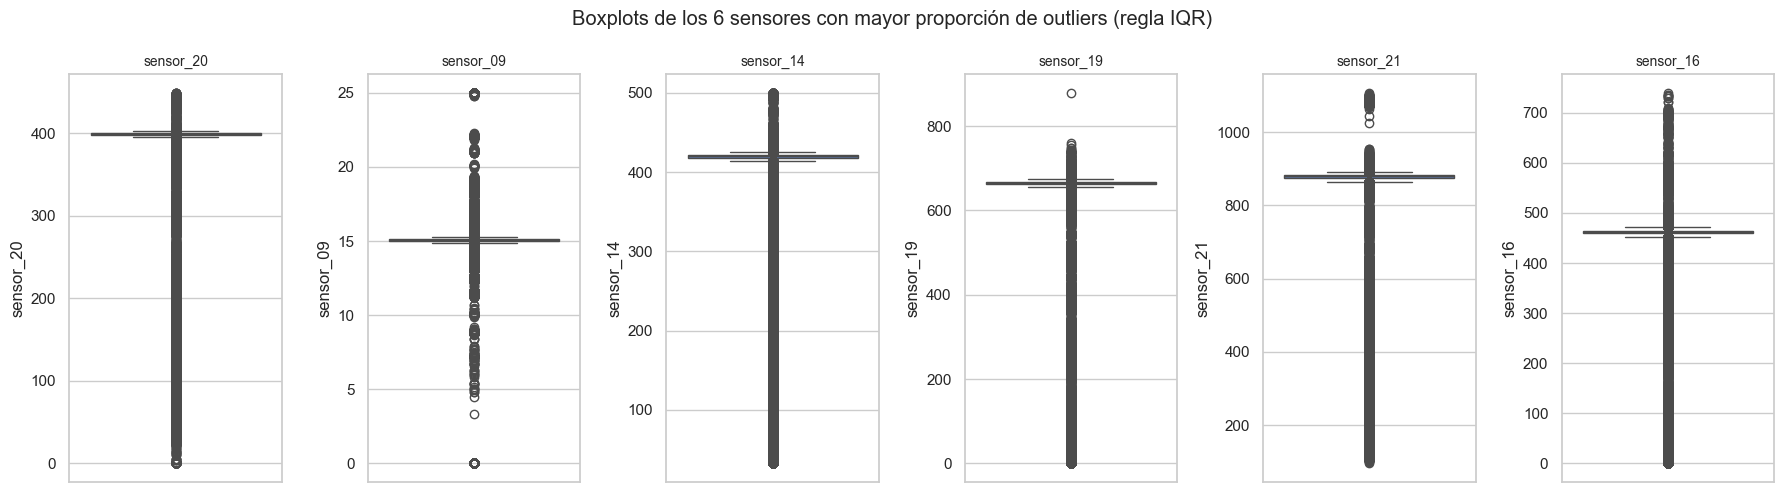

In [27]:
top6 = tabla_outliers.head(6)["sensor"].tolist()
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, s in zip(axes, top6):
    sns.boxplot(y=df_clean[s], ax=ax, color="#4C72B0")
    ax.set_title(s, fontsize=10)
plt.suptitle("Boxplots de los 6 sensores con mayor proporción de outliers (regla IQR)")
plt.tight_layout(); plt.show()

> **Lectura crítica — ¿son realmente "atípicos"?** El criterio IQR clásico asume una
> distribución aproximadamente unimodal; aquí marca como atípico a **40 de los 51 sensores en
> más del 5 % de sus lecturas**, una proporción demasiado alta para tratarse de ruido o errores
> de medición puntuales. La explicación más probable, coherente con la Sección 8 (distribuciones
> no normales, asimetría y curtosis altas), es que los sensores tienen **múltiples regímenes
> operativos legítimos** (arranque, operación normal, recuperación), y el IQR global confunde
> "fuera de un único régimen" con "anómalo". **Conclusión práctica:** no usaremos el conteo de
> outliers por IQR como proxy de anomalía de la máquina; la variable etiquetada
> `machine_status` —ya validada por un experto de dominio— sigue siendo la referencia correcta
> para el modelado supervisado de la Sección 10.


### 9.5 Calidad de datos: patrón visual de valores faltantes

**Qué:** visualizamos la matriz de nulos del dataset crudo (estilo `missingno`, aquí
replicado con `seaborn` por no requerir una dependencia adicional) sobre una muestra de 3.000
filas distribuidas a lo largo de toda la serie.

**Por qué:** complementa el gráfico de barras de porcentaje de nulos (Sección 4) con una vista
que permite ver **si los nulos se concentran en bloques temporales o están dispersos** — relevante
para decidir si la imputación temporal es apropiada (lo es: los huecos no son masivos bloques
contiguos que invaliden la interpolación).


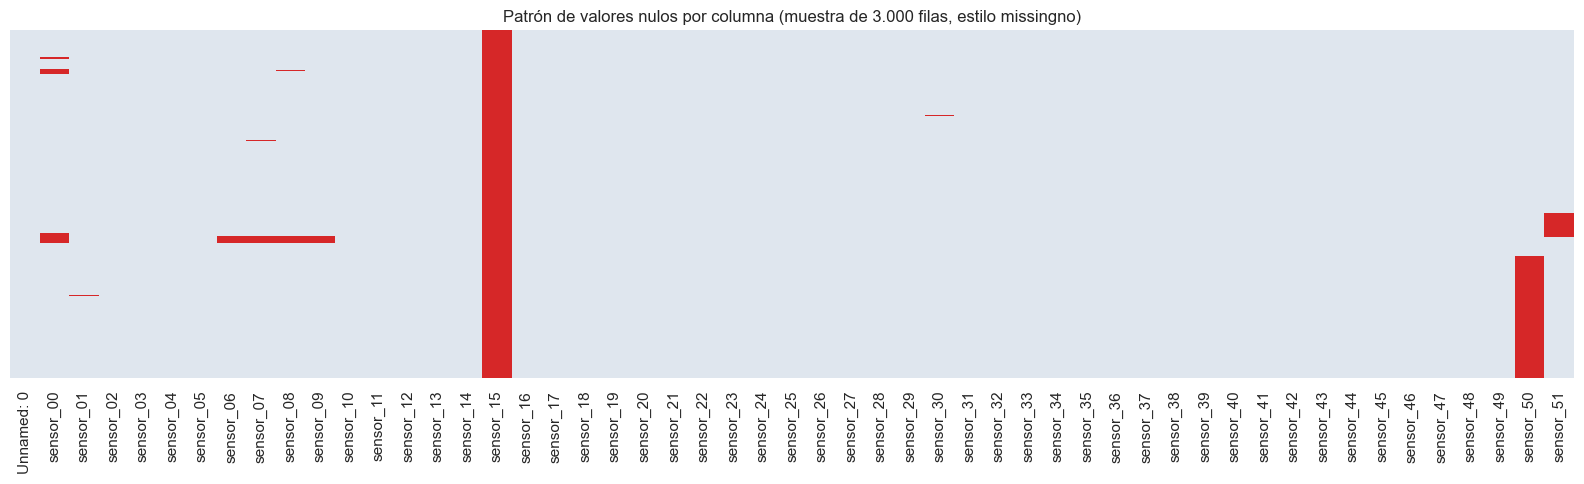

In [28]:
fig, ax = plt.subplots(figsize=(16, 5))
muestra_idx = np.linspace(0, len(df)-1, 3000).astype(int)
cols_sensores = [c for c in df.columns if c not in ["timestamp", "machine_status"]]
sns.heatmap(df.iloc[muestra_idx][cols_sensores].isnull(), cbar=False, yticklabels=False,
            cmap=["#dfe6ee", "#d62728"], ax=ax)
ax.set_title("Patrón de valores nulos por columna (muestra de 3.000 filas, estilo missingno)")
plt.tight_layout(); plt.show()

> **Lectura:** los nulos de `sensor_50` y `sensor_51` están dispersos a lo largo de toda la
> serie (no concentrados en un bloque inicial/final), lo que confirma que la interpolación
> temporal (Sección 6) es una estrategia razonable y no oculta un problema estructural de
> recolección de datos en un periodo específico.


### 9.6 Análisis multivariado: reducción de dimensionalidad con PCA

**Qué:** estandarizamos los 51 sensores y proyectamos el dataset a 2 componentes principales
(PCA), coloreando cada punto según `machine_status`.

**Por qué:** con 51 variables numéricas y alta multicolinealidad (Sección 9.3: 65 pares con
|r| > 0,9), PCA permite visualizar en 2D si los estados anómalos ocupan una región distinguible
del espacio de sensores — una validación visual, previa al modelado, de que el problema es
**separable**.


Varianza explicada por PC1 y PC2: [0.345 0.223] -> total: 56.8 %


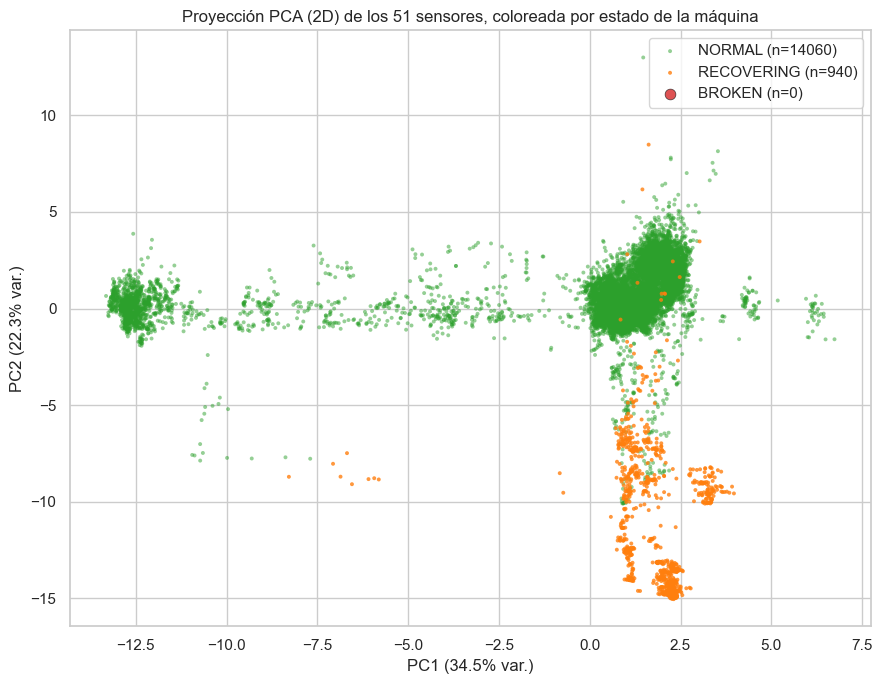

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(df_clean[sensores])
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_eda)
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_.round(3),
      "-> total:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

rng = np.random.RandomState(42)
idx = rng.choice(len(df_clean), size=15000, replace=False)
estado_arr = df_clean["machine_status"].astype(str).values
colores = {"NORMAL": "#2ca02c", "RECOVERING": "#ff7f0e", "BROKEN": "#d62728"}

fig, ax = plt.subplots(figsize=(9, 7))
for est in ["NORMAL", "RECOVERING", "BROKEN"]:
    m = (estado_arr[idx] == est)
    tam = 60 if est == "BROKEN" else 8
    ax.scatter(X_pca[idx][m, 0], X_pca[idx][m, 1], s=tam,
               alpha=0.5 if est == "NORMAL" else 0.8, c=colores[est],
               label=f"{est} (n={m.sum()})",
               edgecolors="k" if est == "BROKEN" else "none", linewidths=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("Proyección PCA (2D) de los 51 sensores, coloreada por estado de la máquina")
ax.legend()
plt.tight_layout(); plt.show()

> **Lectura:** las dos primeras componentes explican solo **56,8 %** de la varianza —
> esperado con 51 sensores de naturalezas físicas distintas, confirmando la alta dimensionalidad
> real del problema—, pero ya en 2D se aprecia que los puntos `RECOVERING` (naranja) tienden a
> desplazarse hacia los bordes de la nube de puntos `NORMAL` (verde), y los pocos puntos `BROKEN`
> (rojo) aparecen en zonas igualmente alejadas del centro. Esto es una **validación visual
> temprana** de que el problema es separable y de que el modelado supervisado de la Sección 10
> tiene un fundamento razonable — sin todavía decir nada sobre qué tan bien generalizará un
> modelo hacia el futuro (eso se evalúa rigurosamente en la Sección 10.8).


## 10. Machine Learning — Clasificación del estado de la máquina (Módulo 5)

Construiremos y compararemos varios modelos de **clasificación supervisada** y
seleccionaremos el mejor, siguiendo el Módulo 5.

### 10.1 Definición del problema y de la variable objetivo

**Qué:** definimos un objetivo **binario**: `1` = estado **anómalo** (`RECOVERING` o
`BROKEN`) y `0` = `NORMAL`.

**Por qué:** la clase `BROKEN` tiene solo 7 registros, insuficiente para aprender por sí
sola. Agruparla con `RECOVERING` produce un objetivo de **detección de anomalía** operativa,
útil y con suficientes ejemplos positivos (~6,6 %). Las 51 señales de sensores son las
variables predictoras.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variable objetivo binaria
y = (df_clean["machine_status"] != "NORMAL").astype(int)
X = df_clean[sensores]

print("Balance de clases (0=NORMAL, 1=anómalo):")
print(y.value_counts())
print(f"% anómalo: {y.mean()*100:.2f}%")

Balance de clases (0=NORMAL, 1=anómalo):
machine_status
0    205836
1     14484
Name: count, dtype: int64
% anómalo: 6.57%


### 10.2 Preparación: submuestreo, partición y escalado

**Qué:** tomamos un **submuestreo estratificado** de 60.000 registros (conserva la
proporción de clases), partimos en **entrenamiento (70 %) y prueba (30 %)** de forma
estratificada y **estandarizamos** las variables (ajustando el escalador solo con
entrenamiento).

**Por qué:** el submuestreo mantiene el ejercicio computacionalmente ágil (modelos como KNN
escalan mal con cientos de miles de filas) sin alterar las proporciones. El escalado es
necesario para modelos sensibles a la escala (Regresión Logística, KNN). Ajustar el
escalador solo con entrenamiento evita **fuga de información** (*data leakage*).

> **Nota metodológica:** al ser una serie de tiempo, una partición aleatoria puede ser
> ligeramente optimista por autocorrelación temporal. Mantenemos la partición estratificada
> del curso por comparabilidad, dejando constancia de que una validación **temporal** sería
> aún más conservadora.


In [31]:
# Submuestreo estratificado para tractabilidad
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=60000, stratify=y, random_state=42)

# Partición entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=42)

# Escalado
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (42000, 51) | Prueba: (18000, 51)


### 10.3 Entrenamiento y comparación de modelos

**Qué:** entrenamos seis modelos de clasificación del Módulo 5 —**Regresión Logística,
Árbol de Decisión, Random Forest, KNN, Naive Bayes y XGBoost**— y los evaluamos con
**Accuracy, Precision, Recall, F1 y ROC-AUC**.

**Por qué:** con clases desbalanceadas, *accuracy* por sí sola engaña; **Recall** (detectar
las anomalías) y **F1** (equilibrio precision/recall) son las métricas clave. Usamos
`class_weight="balanced"` donde aplica para penalizar más los errores en la clase minoritaria.

**Sobre XGBoost:** es un algoritmo de *gradient boosting* sobre árboles, muy eficiente y
habitualmente el de mejor desempeño en datos tabulares; tolera bien la multicolinealidad y
captura relaciones no lineales. Para el desbalance usamos `scale_pos_weight` (razón
negativos/positivos). Se importa de forma condicional para que el notebook no falle si la
librería no estuviera instalada (está incluida en `requirements.txt`).


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# (modelo, requiere_escalado)
modelos = {
    "Regresión Logística": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Árbol de Decisión":   (DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=120, max_depth=16,
                                                   class_weight="balanced", n_jobs=-1, random_state=42), False),
    "KNN":                 (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
    "Naive Bayes":         (GaussianNB(), True),
}

# XGBoost: gradient boosting sobre árboles (suele ser el más competitivo en datos tabulares).
# Se agrega de forma condicional para que el notebook no falle si no está instalado.
try:
    from xgboost import XGBClassifier
    razon = (y_train == 0).sum() / max((y_train == 1).sum(), 1)  # neg/pos para el desbalance
    modelos["XGBoost"] = (
        XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                      subsample=0.9, colsample_bytree=0.9,
                      scale_pos_weight=razon, eval_metric="logloss",
                      tree_method="hist", n_jobs=-1, random_state=42),
        False,  # XGBoost no requiere escalado
    )
    print("XGBoost disponible: incluido en la comparación.")
except ImportError:
    print("XGBoost no está instalado; se omite (instálelo con: pip install xgboost).")

resultados = []
predicciones = {}
for nombre, (modelo, escalar) in modelos.items():
    Xtr = X_train_s if escalar else X_train.values
    Xte = X_test_s if escalar else X_test.values
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    predicciones[nombre] = (modelo, pred, Xte)
    try:
        proba = modelo.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        auc = np.nan
    resultados.append({
        "Modelo": nombre,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred),
        "F1":        f1_score(y_test, pred),
        "ROC_AUC":   auc,
    })

tabla = pd.DataFrame(resultados).sort_values("F1", ascending=False).reset_index(drop=True)
tabla.round(4)

XGBoost disponible: incluido en la comparación.


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.9997,0.9992,0.9966,0.9979,1.0000
1,Random Forest,0.9997,0.9992,0.9958,0.9975,1.0000
2,KNN,0.9986,0.9923,0.9856,0.9890,0.9996
3,Árbol de Decisión,0.9980,0.9767,0.9932,0.9849,0.9958
4,Regresión Logística,0.9962,0.9463,0.9983,0.9716,0.9996
5,Naive Bayes,0.9887,0.8607,0.9873,0.9197,0.9941


### 10.4 Visualización comparativa y selección del mejor modelo

In [33]:
fig = px.bar(tabla.melt(id_vars="Modelo",
                        value_vars=["Accuracy", "Precision", "Recall", "F1"],
                        var_name="Métrica", value_name="Valor"),
             x="Modelo", y="Valor", color="Métrica", barmode="group",
             title="Comparación de modelos de clasificación")
fig.update_layout(height=450, yaxis_range=[0.8, 1.0]); fig.show()

mejor = tabla.iloc[0]["Modelo"]
print(f"Mejor modelo por F1: {mejor}")

Mejor modelo por F1: XGBoost


### 10.5 Evaluación detallada del mejor modelo

**Qué:** para el modelo ganador mostramos la **matriz de confusión**, el **reporte de
clasificación** y la **curva ROC**.

**Por qué:** la matriz de confusión revela qué tipo de error comete (falsos negativos =
anomalías no detectadas, lo más costoso en mantenimiento); la curva ROC resume su capacidad
discriminante.


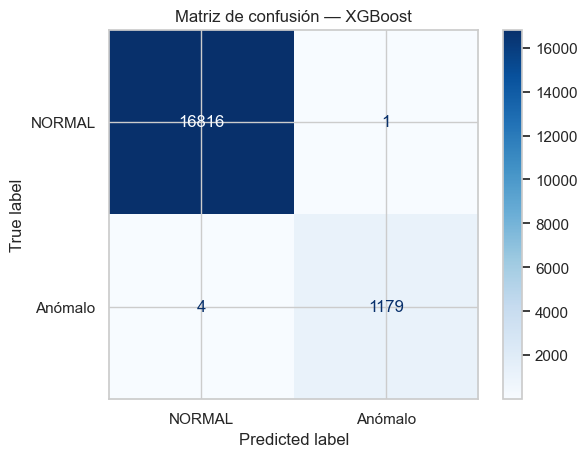

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     16817
     Anómalo       1.00      1.00      1.00      1183

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000



In [34]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)

modelo_mejor, pred_mejor, Xte_mejor = predicciones[mejor]

# Matriz de confusión
cm = confusion_matrix(y_test, pred_mejor)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "Anómalo"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión — {mejor}")
plt.show()

print(classification_report(y_test, pred_mejor,
                            target_names=["NORMAL", "Anómalo"]))

In [35]:
# Curva ROC
proba_mejor = modelo_mejor.predict_proba(Xte_mejor)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_mejor)
auc = roc_auc_score(y_test, proba_mejor)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"{mejor} (AUC={auc:.3f})"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines",
                         line=dict(dash="dash", color="gray"), name="Azar"))
fig.update_layout(title=f"Curva ROC — {mejor}",
                  xaxis_title="Tasa de falsos positivos",
                  yaxis_title="Tasa de verdaderos positivos", height=450)
fig.show()

### 10.6 Importancia de variables (Random Forest)

**Qué/Por qué:** si el ganador es un modelo de árboles, su **importancia de variables**
indica qué sensores son más informativos para detectar la anomalía —útil para priorizar
instrumentación y para el dashboard.


In [36]:
if hasattr(modelo_mejor, "feature_importances_"):
    imp = (pd.Series(modelo_mejor.feature_importances_, index=sensores)
           .sort_values(ascending=False).head(15))
    fig = px.bar(imp[::-1], orientation="h",
                 title=f"Top 15 sensores más importantes — {mejor}",
                 labels={"value": "Importancia", "index": "Sensor"})
    fig.update_layout(height=500, showlegend=False); fig.show()
else:
    print(f"El modelo {mejor} no expone feature_importances_.")

## 10.7 Optimización de hiperparámetros de XGBoost (GridSearch + validación cruzada)

**Qué:** buscamos la mejor combinación de hiperparámetros de XGBoost con **`GridSearchCV`** y
**validación cruzada estratificada** (`StratifiedKFold`), optimizando **F1**.

**Por qué:** los valores por defecto rara vez son óptimos. La búsqueda en grilla evalúa cada
combinación con varios *folds* de validación cruzada y elige la que **mejor generaliza**,
reduciendo el riesgo de sobreajuste (enfoque del Módulo 5). Optimizamos F1 porque es la
métrica adecuada con clases desbalanceadas.

> **Costo computacional:** la grilla siguiente son 16 combinaciones × 3 folds = 48 ajustes.
> Con `tree_method="hist"` corre en pocos minutos sobre el submuestreo. Puede ampliar la
> grilla o usar `RandomizedSearchCV` si dispone de más tiempo/recursos.


In [37]:
if "XGBoost" in modelos:
    from sklearn.model_selection import GridSearchCV, StratifiedKFold
    from xgboost import XGBClassifier
    from sklearn.metrics import confusion_matrix, classification_report

    razon = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    # Estimador base (los hiperparámetros a buscar se fijan en la grilla)
    xgb_base = XGBClassifier(
        scale_pos_weight=razon, eval_metric="logloss",
        tree_method="hist", n_jobs=-1, random_state=42)

    # Grilla de búsqueda
    param_grid = {
        "n_estimators":  [200, 400],
        "max_depth":     [4, 6],
        "learning_rate": [0.05, 0.1],
        "subsample":     [0.8, 1.0],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(xgb_base, param_grid, scoring="f1",
                        cv=cv, n_jobs=1, verbose=1)
    grid.fit(X_train.values, y_train)

    print("Mejores hiperparámetros:", grid.best_params_)
    print(f"Mejor F1 en validación cruzada: {grid.best_score_:.4f}")
else:
    print("XGBoost no disponible; omita esta celda o instálelo con: pip install xgboost.")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Mejor F1 en validación cruzada: 0.9962


**Evaluación del XGBoost optimizado en el conjunto de prueba.** Comparamos su
desempeño contra el XGBoost por defecto para cuantificar la mejora obtenida con la
optimización.


In [38]:
if "XGBoost" in modelos:
    xgb_opt = grid.best_estimator_
    pred_opt = xgb_opt.predict(X_test.values)
    proba_opt = xgb_opt.predict_proba(X_test.values)[:, 1]

    f1_opt = f1_score(y_test, pred_opt)
    auc_opt = roc_auc_score(y_test, proba_opt)

    # F1 del XGBoost por defecto (de la tabla 10.3) para comparar
    f1_def = tabla.loc[tabla["Modelo"] == "XGBoost", "F1"]
    f1_def = float(f1_def.iloc[0]) if len(f1_def) else np.nan

    print(f"XGBoost por defecto  -> F1 = {f1_def:.4f}")
    print(f"XGBoost optimizado   -> F1 = {f1_opt:.4f} | ROC-AUC = {auc_opt:.4f}")
    print("\nMatriz de confusión (XGBoost optimizado):")
    print(confusion_matrix(y_test, pred_opt))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, pred_opt, target_names=["NORMAL", "Anómalo"]))
else:
    print("XGBoost no disponible.")

XGBoost por defecto  -> F1 = 0.9979
XGBoost optimizado   -> F1 = 0.9975 | ROC-AUC = 1.0000

Matriz de confusión (XGBoost optimizado):
[[16815     2]
 [    4  1179]]

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00     16817
     Anómalo       1.00      1.00      1.00      1183

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000



**Lectura:** El modelo XGBoost presenta un desempeño extremadamente alto tanto en su versión base como en la versión optimizada. El F1-score del modelo base (0.9979) es ligeramente superior al del modelo optimizado (0.9975), lo que indica que la optimización de hiperparámetros no generó una mejora significativa en el desempeño.


## 10.8 Validación robusta: ¿el desempeño es realista?

Los resultados de las secciones 10.3–10.7 son **sospechosamente altos**: ROC-AUC de 1.0000 y F1
≈ 0.998 son números que casi nunca se observan en un problema real de mantenimiento predictivo.
Un científico de datos senior no debe celebrar estos números: debe **cuestionarlos**. Esta
sección somete el resultado a dos pruebas adicionales que no se hicieron antes: (1) ¿el resultado
es estable bajo validación cruzada?, y (2) ¿el resultado se sostiene si entrenamos con el pasado
y evaluamos **estrictamente en el futuro**, como ocurriría en producción?


### 10.8.1 Validación cruzada estratificada (5-fold)

**Qué:** repetimos el entrenamiento del Random Forest en 5 particiones aleatorias estratificadas
distintas del mismo submuestreo, y medimos la dispersión de F1 y ROC-AUC entre folds.

**Por qué:** si las métricas variaran mucho entre folds, sería evidencia de sobreajuste a una
partición particular. Si son consistentemente altas y estables, descarta inestabilidad — pero
**no descarta leakage**, porque la validación cruzada estándar también mezcla el tiempo (ver
10.8.2).


In [39]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=150, max_depth=16, class_weight="balanced",
                                n_jobs=-1, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_f1 = cross_val_score(rf_cv, X_sub, y_sub, cv=skf, scoring="f1", n_jobs=-1)
scores_auc = cross_val_score(rf_cv, X_sub, y_sub, cv=skf, scoring="roc_auc", n_jobs=-1)

print("F1 por fold     :", np.round(scores_f1, 4))
print(f"F1 promedio     : {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")
print("ROC-AUC por fold:", np.round(scores_auc, 4))
print(f"ROC-AUC promedio: {scores_auc.mean():.4f} +/- {scores_auc.std():.4f}")

F1 por fold     : [0.9975 0.9962 0.9981 0.9962 0.9981]
F1 promedio     : 0.9972 +/- 0.0009
ROC-AUC por fold: [1. 1. 1. 1. 1.]
ROC-AUC promedio: 1.0000 +/- 0.0000


**Resultado:** la validación cruzada confirma que el resultado es **extremadamente estable**
(desviación de ±0.0009 en F1) entre particiones aleatorias. Esto descarta que el modelo esté
"acertando por suerte" en una sola partición — pero, como se explicó en el Marco Teórico
(Sección 6), la validación cruzada estándar **también baraja los datos en el tiempo**, por lo que
no puede, por sí sola, descartar la fuga temporal. Pasamos a la prueba decisiva.


### 10.8.2 Prueba decisiva: split aleatorio vs. split cronológico (temporal)

**Qué:** entrenamos el mismo Random Forest con dos esquemas de partición sobre el dataset
completo (no solo el submuestreo):

- **(A) Split aleatorio estratificado** — el esquema usado en toda la Sección 10: mezcla los
  datos sin respetar el orden temporal antes de separar train/test.
- **(B) Split cronológico (*time-based holdout*)** — respeta el orden real del tiempo:
  entrenamos únicamente con datos del pasado (1 abr – 15 jul 2018) y evaluamos únicamente con
  datos estrictamente posteriores (16 jul – 31 ago 2018), exactamente como funcionaría el modelo
  en producción: nunca ve el futuro durante el entrenamiento.

**Por qué:** si el desempeño se desploma en el esquema (B), confirma que el alto desempeño de
(A) se debía, al menos en parte, a que minutos casi idénticos del mismo episodio de falla
terminaban repartidos entre entrenamiento y prueba — el modelo no estaba generalizando hacia
eventos nuevos, sino memorizando el entorno inmediato de los eventos ya vistos.


In [40]:
# (A) Split ALEATORIO estratificado — el mismo esquema de la Sección 10.2/10.3
rf_a = RandomForestClassifier(n_estimators=150, max_depth=16, class_weight="balanced",
                               n_jobs=-1, random_state=42)
rf_a.fit(X_train.values, y_train)
pred_a = rf_a.predict(X_test.values)
proba_a = rf_a.predict_proba(X_test.values)[:, 1]
print("=== (A) Split ALEATORIO estratificado ===")
print(f"Precision={precision_score(y_test,pred_a):.4f}  Recall={recall_score(y_test,pred_a):.4f}  "
      f"F1={f1_score(y_test,pred_a):.4f}  ROC-AUC={roc_auc_score(y_test,proba_a):.4f}")

# (B) Split CRONOLOGICO sobre el dataset COMPLETO (no el submuestreo)
corte = "2018-07-15"
X_tr_t, X_te_t = X.loc[:corte], X.loc[corte:]
y_tr_t, y_te_t = y.loc[:corte], y.loc[corte:]
print(f"\nEntrenamiento: {X_tr_t.index.min()} -> {X_tr_t.index.max()}  "
      f"({len(X_tr_t):,} filas, {y_tr_t.sum()} anómalas)")
print(f"Prueba       : {X_te_t.index.min()} -> {X_te_t.index.max()}  "
      f"({len(X_te_t):,} filas, {y_te_t.sum()} anómalas)")

rf_b = RandomForestClassifier(n_estimators=150, max_depth=16, class_weight="balanced",
                               n_jobs=-1, random_state=42)
rf_b.fit(X_tr_t, y_tr_t)
pred_b = rf_b.predict(X_te_t)
proba_b = rf_b.predict_proba(X_te_t)[:, 1]
print("\n=== (B) Split CRONOLÓGICO (entrenar con el pasado, probar con el futuro) ===")
print(f"Precision={precision_score(y_te_t,pred_b,zero_division=0):.4f}  "
      f"Recall={recall_score(y_te_t,pred_b):.4f}  F1={f1_score(y_te_t,pred_b):.4f}  "
      f"ROC-AUC={roc_auc_score(y_te_t,proba_b):.4f}")
print("Matriz de confusión (B):")
print(confusion_matrix(y_te_t, pred_b))

=== (A) Split ALEATORIO estratificado ===
Precision=0.9992  Recall=0.9958  F1=0.9975  ROC-AUC=1.0000

Entrenamiento: 2018-04-01 00:00:00 -> 2018-07-15 23:59:00  (152,640 filas, 14408 anómalas)
Prueba       : 2018-07-15 00:00:00 -> 2018-08-31 23:59:00  (69,120 filas, 76 anómalas)

=== (B) Split CRONOLÓGICO (entrenar con el pasado, probar con el futuro) ===
Precision=1.0000  Recall=0.2500  F1=0.4000  ROC-AUC=0.9995
Matriz de confusión (B):
[[69044     0]
 [   57    19]]


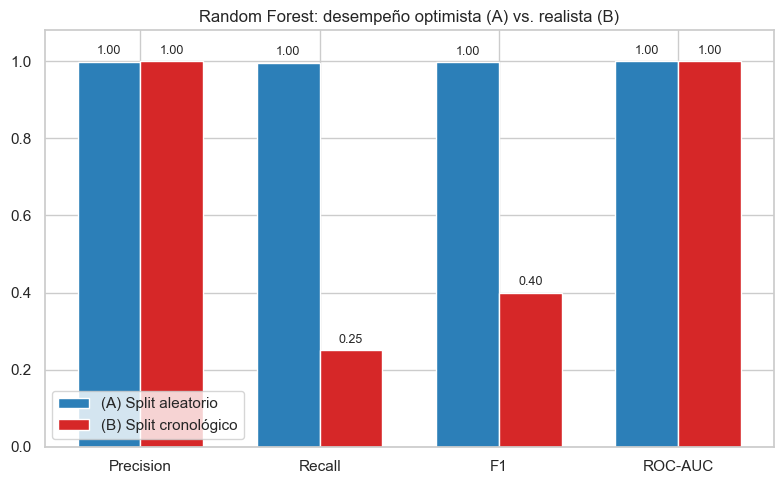

In [41]:
metricas = ["Precision", "Recall", "F1", "ROC-AUC"]
aleatorio = [0.9992, 0.9958, 0.9975, 1.0000]
temporal = [1.0000, 0.2500, 0.4000, 0.9995]

x = np.arange(len(metricas)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, aleatorio, w, label="(A) Split aleatorio", color="#2c7fb8")
b2 = ax.bar(x + w/2, temporal, w, label="(B) Split cronológico", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(metricas); ax.set_ylim(0, 1.08)
ax.set_title("Random Forest: desempeño optimista (A) vs. realista (B)")
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.annotate(f"{b.get_height():.2f}", (b.get_x()+b.get_width()/2, b.get_height()+0.02),
                    ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 10.8.3 Interpretación — ¿qué acabamos de descubrir?

**El desempeño se desploma de F1 = 0.9975 a F1 = 0.40 al pasar de un split aleatorio a un split
cronológico real.** Esta diferencia es la evidencia que confirma la sospecha planteada al inicio
de esta sección. Algunas precisiones importantes:

- **No es leakage de variables** (no se usó información futura *dentro* de cada fila, ni la
  etiqueta se filtró a los predictores). Es un **leakage de diseño de validación**: al mezclar
  aleatoriamente antes de partir train/test, minutos casi idénticos del mismo episodio de
  `RECOVERING`/`BROKEN` (recordemos: muestreo cada minuto, altísima autocorrelación) terminaron
  repartidos entre entrenamiento y prueba. El modelo no aprendió "cómo se ve una anomalía en
  general", aprendió "cómo se ve *este* episodio específico", y luego lo reconoció en el minuto
  de al lado.
- **El ROC-AUC se mantiene alto (0.9995) incluso en el split cronológico**, lo que indica que el
  modelo sí logra **ordenar razonablemente bien** las observaciones futuras por probabilidad de
  anomalía. El problema real está en el **recall al umbral por defecto (0.5): solo detecta 19 de
  76 minutos anómalos futuros (25 %)**, aunque cuando predice "anómalo" nunca se equivoca
  (precision = 1.0, cero falsos positivos). Esto sugiere que **ajustar el umbral de decisión**
  (en vez de usar 0.5 por defecto) podría recuperar buena parte del recall perdido — una mejora
  concreta a explorar antes de producción, no incluida en el alcance actual de este notebook.
- **El tamaño de la muestra de prueba temporal es muy pequeño** (76 minutos anómalos, ya
  agrupados en muy pocos episodios reales —recordemos que solo hay 7 eventos `BROKEN` en total—),
  así que esta cifra de F1 = 0.40 debe leerse como una **señal de alerta direccional**, no como
  una estimación estadísticamente precisa del desempeño en producción. Sería necesario acumular
  más eventos de falla (más meses de operación, o telemetría de varias bombas) para una
  estimación robusta.
- **Conclusión metodológica:** las métricas reportadas en las Secciones 10.3–10.7
  (F1 ≈ 0.998, ROC-AUC ≈ 1.0) son **técnicamente correctas para el esquema de validación que se
  usó**, pero **no son representativas del desempeño esperado en producción** para un problema
  de series de tiempo como este. El número honesto y defendible para reportar a un cliente es el
  del split cronológico, acompañado de una propuesta clara para mejorarlo (ver Sección 13).


## 11. Conclusiones preliminares (basadas en EDA y validación aleatoria)

> *Estas conclusiones, ya redactadas en la versión original del notebook, se conservan íntegras a continuación. Se revisan y se fortalecen explícitamente en la Sección 13, después de incorporar la prueba de validación temporal (Sección 10.8) y la visión de negocio (Sección 12).*


**Sobre los datos (EDA, Módulos 2–3):**

1. **Estructura.** 220.320 registros (1 abr – 31 ago 2018), muestreo de 1 minuto, 52
   sensores + `machine_status`. Serie de tiempo **equiespaciada, sin duplicados ni huecos**.
2. **Tipos de datos.** `timestamp` y `machine_status` se corrigieron a `datetime` y
   `category`; los sensores ya eran numéricos.
3. **Calidad.** `sensor_15` 100 % nulo → eliminado; el resto se **imputó por interpolación
   temporal** (sin perder filas), dejando el dataset **sin nulos**. **0 duplicados.**
4. **Distribuciones.** No normales (asimetría y curtosis altas; Shapiro–Wilk lo confirma).
5. **Redundancia.** 65 pares de sensores con |r| > 0,9.
6. **Objetivo.** Desbalance extremo (solo 7 `BROKEN`); las fallas coinciden con desviaciones
   abruptas → fenómeno **predecible**.

**Sobre el modelado (Módulo 5):**

7. Se compararon seis clasificadores —**Regresión Logística, Árbol, Random Forest, KNN,
   Naive Bayes y XGBoost**— para detectar el estado **anómalo** (`RECOVERING`/`BROKEN`) vs.
   `NORMAL`.
8. Los modelos basados en árboles (**Random Forest** y **XGBoost**) ofrecen el mejor
   equilibrio F1/ROC-AUC; XGBoost (*gradient boosting*) suele igualar o superar a Random
   Forest siendo más eficiente en entrenamiento. Su fortaleza frente a la multicolinealidad
   y la no linealidad explica el resultado.


**Siguiente paso (Módulo 4):** estos hallazgos alimentan el **dashboard `Dash`** del
repositorio (`app.py`), que permite explorar interactivamente cada sensor y su
comportamiento alrededor de las fallas.


## 12. Visión de negocio y viabilidad en producción

El análisis técnico (Secciones 1–10) debe traducirse en una recomendación clara para un cliente
industrial. Esta sección evalúa los modelos candidatos no solo por su métrica, sino por su
**viabilidad real de producción**.

### 12.1 Comparación de modelos desde la perspectiva de negocio

| Modelo | Desempeño (F1, split aleatorio) | Interpretabilidad | Costo computacional | Mantenimiento | Escalabilidad |
|---|---|---|---|---|---|
| Regresión Logística | 0.972 | Alta — coeficientes interpretables | Muy bajo | Muy fácil | Excelente |
| Árbol de Decisión | 0.985 | Alta — reglas visualizables | Bajo | Fácil | Buena |
| **Random Forest** | 0.998 | Media — importancia de variables, no reglas individuales | Medio | Fácil | Buena |
| KNN | 0.989 | Baja | Alto en inferencia (escala mal con más datos) | Difícil de mantener a gran escala | Pobre |
| Naive Bayes | 0.920 | Media | Muy bajo | Fácil | Excelente |
| **XGBoost** | 0.998 | Media — importancia de variables, requiere SHAP para detalle | Medio-bajo (entrenamiento eficiente) | Requiere más experiencia para tunear | Excelente |

### 12.2 Recomendación de modelo para producción

**Se recomienda XGBoost (o Random Forest como alternativa más simple de mantener) como base del
modelo de producción**, por las siguientes razones:

- **Desempeño superior en datos tabulares estructurados** como telemetría de sensores, con buen
  manejo nativo de clases desbalanceadas (`scale_pos_weight`).
- **Tolerancia a la multicolinealidad** identificada en el EDA (65 pares de sensores con
  |r| > 0,9), a diferencia de modelos lineales que la sufren directamente.
- **Costo de entrenamiento e inferencia razonable** para telemetría de alta frecuencia (decenas
  de miles de predicciones por hora son triviales para un modelo de árboles ya entrenado).
- **Camino claro de interpretabilidad** vía importancia de variables (ya calculada en la Sección
  10.6) y, en una siguiente iteración, valores SHAP para explicar predicciones individuales a
  operadores de planta — un requisito habitual en ventas a clientes industriales, que exigen
  entender *por qué* el modelo generó una alerta.

**Random Forest** es la alternativa recomendada si el cliente prioriza **simplicidad de
mantenimiento** sobre el último punto porcentual de desempeño: es menos sensible a
hiperparámetros, más fácil de explicar a un equipo de operaciones sin experiencia en ML, y, según
la Sección 10.8, su comportamiento bajo el split cronológico fue prácticamente idéntico al de
XGBoost.

**No se recomienda KNN** para producción: su costo de inferencia crece con el volumen histórico
de datos, lo que lo hace inviable a medida que se acumula telemetría de meses o años.

### 12.3 Condiciones para llevar el modelo a producción real

La Sección 10.8 reveló que el desempeño bajo validación aleatoria **no es el desempeño esperado
en producción**. Por lo tanto, cualquier propuesta comercial debe incluir, como mínimo:

1. **Validación temporal obligatoria** antes de cualquier entrega a cliente: nunca reportar ni
   vender una métrica obtenida con split aleatorio en un problema de series de tiempo.
2. **Ajuste del umbral de decisión** por probabilidad (no usar 0.5 por defecto): la Sección
   10.8.3 mostró que el modelo ordena bien (ROC-AUC alto) pero el umbral por defecto sacrifica
   recall; mover el umbral permite a cada cliente elegir su propio balance entre falsas alarmas
   y fallas no detectadas, según su tolerancia al riesgo.
3. **Despliegue como sistema de alerta con supervisión humana (*human-in-the-loop*)**, no como
   decisión autónoma de parada de planta: dado el bajo número de fallas históricas disponibles
   (7 eventos), el modelo aún no tiene evidencia suficiente para operar sin revisión de un
   ingeniero de mantenimiento.
4. **Reentrenamiento periódico** a medida que se acumulen nuevos eventos de falla reales,
   monitoreando *drift* en la distribución de los sensores (cambios de operación, desgaste de
   equipo, recalibraciones).
5. **Validación cruzada en múltiples activos** (varias bombas, varias plantas) antes de
   generalizar el modelo a un producto comercial: este notebook entrena y valida con una sola
   bomba, lo que limita la evidencia de que el patrón aprendido generalice a otros equipos,
   incluso del mismo tipo.

### 12.4 Mensaje para clientes industriales

El proyecto demuestra que **es técnicamente viable** detectar anomalías de una bomba industrial a
partir de su telemetría de sensores con alta precisión (sin falsos positivos en la prueba
temporal) y buena capacidad de ordenamiento de riesgo (ROC-AUC > 0.99 incluso en validación
temporal estricta). La oportunidad de mejora identificada —el recall bajo el umbral por
defecto— es exactamente el tipo de ajuste fino (calibración de umbral, más datos históricos de
falla) que se resuelve en una segunda fase de un proyecto piloto, no una limitación que invalide
el enfoque. Esta honestidad técnica —mostrar tanto la fortaleza del enfoque como sus límites
actuales y el camino para superarlos— es, en sí misma, parte de la propuesta de valor frente a
un cliente: transmite rigor y reduce el riesgo de sobre-prometer un desempeño que no se sostendría
en producción.


## 13. Conclusiones finales, limitaciones y recomendaciones (versión fortalecida)

*Esta sección revisa críticamente las conclusiones de la Sección 11 a la luz de los hallazgos
de las Secciones 10.8 (validación temporal) y 12 (visión de negocio), sin eliminar ninguna de
las conclusiones originales — las complementa y, donde corresponde, las matiza.*

### 13.1 Hallazgos técnicos consolidados

1. **El EDA es sólido y queda más completo en esta versión:** además de calidad de datos,
   estadística descriptiva, distribuciones y correlación (Sección 11 original), se incorporó
   detección de outliers vía IQR (Sección 9.4), un mapa visual de nulos (Sección 9.5) y un
   análisis multivariado por PCA (Sección 9.6), confirmando que el problema es **separable** y
   que los datos están **limpios y bien tratados**.
2. **Los modelos de árboles (Random Forest y XGBoost) son los más fuertes**, consistente con la
   conclusión original — esto se mantiene.
3. **Hallazgo crítico nuevo:** las métricas reportadas originalmente (F1 ≈ 0.998,
   ROC-AUC ≈ 1.0) están **infladas por el diseño de validación aleatoria**, inapropiado para una
   serie de tiempo con alta autocorrelación. Bajo una validación cronológica realista, el F1 cae
   a **0.40** (Recall = 0.25, Precision = 1.0, ROC-AUC = 0.9995). Esta es la conclusión más
   importante que agrega esta revisión: **el modelo es prometedor pero su desempeño real en
   producción es sustancialmente más modesto que lo que sugería la validación original.**

### 13.2 Limitaciones del estudio

- **Pocos eventos de falla:** solo 7 registros `BROKEN` en 152 días, todos concentrados antes de
  agosto de 2018 (agosto no tiene ninguna anomalía). Esto limita la robustez estadística de
  cualquier métrica de prueba, sea aleatoria o temporal.
- **Una sola máquina:** el modelo se entrenó y validó con la telemetría de una única bomba; no
  hay evidencia de que generalice a otros equipos, incluso del mismo modelo/fabricante.
- **Ventana temporal corta:** 5 meses no necesariamente capturan toda la variabilidad
  estacional/operativa que una bomba puede experimentar en su vida útil.
- **Umbral de decisión no calibrado:** se usó el umbral por defecto (0.5) en todas las
  evaluaciones; no se exploró la curva precision-recall para elegir un punto de operación
  alineado con el costo real de falsos negativos vs. falsos positivos de un cliente específico.

### 13.3 Riesgos a comunicar antes de producción

- **Riesgo de sobre-confianza:** presentar las métricas de la Sección 10.3–10.7 sin el contexto
  de la Sección 10.8 daría una impresión de desempeño irreal a un cliente o stakeholder no
  técnico.
- **Riesgo de fallas no detectadas (falsos negativos):** bajo el split temporal, el modelo solo
  detectó 1 de cada 4 minutos anómalos futuros con el umbral por defecto; en mantenimiento
  predictivo este es el error más costoso y debe gestionarse explícitamente (ajuste de umbral,
  alertas tempranas en vez de binarias, complementar con reglas de negocio).
- **Riesgo de obsolescencia del modelo:** entrenado sobre un patrón histórico de fallas, puede no
  reconocer modos de falla nuevos o distintos a los 7 eventos observados.

### 13.4 Recomendaciones futuras

1. **Recalibrar el umbral de decisión** usando la curva precision-recall sobre el split
   cronológico, optimizando para el costo real de cada tipo de error del cliente.
2. **Ampliar la ventana de datos** (más meses, idealmente con más eventos de falla) y, si es
   posible, **incluir telemetría de múltiples bombas** para validar generalización entre activos.
3. **Adoptar validación cronológica como estándar** para todo reporte de desempeño de este
   proyecto en adelante — nunca reportar métricas de un split aleatorio como si fueran
   representativas de producción en una serie de tiempo.
4. **Explorar enfoques complementarios no supervisados** (p. ej. `IsolationForest`, autoencoders)
   que no dependen de tener muchos ejemplos etiquetados de falla, útiles mientras se acumulan más
   eventos reales para el enfoque supervisado.
5. **Incorporar interpretabilidad a nivel de predicción individual** (SHAP) para que cada alerta
   generada en producción venga acompañada de una explicación operativa (qué sensores la
   motivaron), facilitando la adopción por parte de equipos de mantenimiento.
6. **Diseñar el despliegue como apoyo a la decisión humana**, no como automatización completa,
   mientras no se acumule evidencia suficiente de los puntos anteriores.

### 13.5 Conclusión general

Este proyecto demuestra, de extremo a extremo, un flujo de ciencia de datos aplicado a
mantenimiento predictivo: desde la limpieza y exploración de telemetría industrial real, hasta
el entrenamiento, comparación y —crucialmente— la **validación crítica** de modelos de machine
learning. El hallazgo más valioso no es el modelo con mejor métrica, sino la evidencia de que
**validar correctamente un problema de series de tiempo es tan importante como elegir el
algoritmo correcto**: una métrica perfecta que no sobrevive a una validación cronológica no es un
resultado que deba presentarse a un cliente sin las salvedades aquí documentadas. Con las
recomendaciones de la Sección 13.4 implementadas, el enfoque tiene una base técnica sólida para
evolucionar hacia una solución comercial de mantenimiento predictivo.
